In [ ]:
# PS C:\Users\EmmaGolub\Desktop\MRoS_local> conda activate C:\Users\EmmaGolub\Desktop\MRoS_local\venv

"""
Resampling PRISM and IMERG for ML predictors

Workflow
  - PRISM daily parquet (800 m)  -> hourly 1 km fields
  - IMERG hourly parquet         -> aligned 1 km fields
  - Output: NetCDF predictor cube (time , y, x)

Assumptions:
  - PRISM parquet columns:
      lon, lat, date, ppt, tmin, tmean, tmax, tdmean
  - IMERG parquet already hourly after 'preprocessing.ipynb' with:
      time, lon, lat, plp
  - DEM_1km_clipped.tif defining te grid
"""

# Imports
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import rasterio
from rasterio.enums import Resampling
from pathlib import Path


In [36]:
# --------------------------- CONFIG ---------------------------------
BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)

PRISM_PARQUET = BASE_DIR / "data/PRISM/combined_prism_20241001_20250601.parquet"
IMERG_PARQUET = BASE_DIR / "outputs/hourly_pipeline/hourly_data/imerg_hourly.parquet"

DEM_PATH = BASE_DIR / "DEM_1km_clipped.tif"

OUT_DIR = BASE_DIR / "outputs/hourly_pipeline"
IMERG_OUT = OUT_DIR / "imerg_hourly_1km.nc"
PRISM_OUT = OUT_DIR / "prism_hourly_1km.nc"



BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype


In [13]:
# open DEM
with rasterio.open(DEM_PATH) as src:
    TEMPLATE_CRS = src.crs
    TEMPLATE_TRANSFORM = src.transform
    NY, NX = src.height, src.width

# Helper: diurnal temperature interpolation
def diurnal_temperature(tmin, tmax, hour):
    """
    Simple physically reasonable diurnal cycle:
      - Tmin ~ 06:00
      - Tmax ~ 15:00
    """
    phase = (hour - 6) / 24.0 * 2 * np.pi
    return tmin + 0.5 * (tmax - tmin) * (1 + np.cos(np.pi - phase))

In [14]:
# 1. Load + inspect PRISM parquet
prism = pd.read_parquet(PRISM_PARQUET)

prism.head()
prism.info()
prism.describe()

prism["date"] = pd.to_datetime(prism["date"])

# Basic cleaning (conservative)
prism = prism.dropna(subset=["lon", "lat", "date"])
prism.loc[prism["ppt"] < 0, "ppt"] = 0
prism.loc[(prism["tmin"] < -60) | (prism["tmax"] > 50),
          ["tmin", "tmean", "tmax", "tdmean"]] = np.nan

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47433600 entries, 0 to 47433599
Data columns (total 8 columns):
 #   Column  Dtype  
---  ------  -----  
 0   lon     float64
 1   lat     float64
 2   tmin    float64
 3   tmean   float64
 4   tmax    float64
 5   tdmean  float64
 6   date    object 
 7   ppt     float64
dtypes: float64(7), object(1)
memory usage: 2.8+ GB


<xarray.Dataset> Size: 348MB
Dimensions:      (time: 244, y: 251, x: 142)
Coordinates:
  * x            (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * y            (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 2kB 2024-10-01 2024-10-02 ... 2025-06-01
Data variables:
    tmin         (time, y, x) float64 70MB 9.823 8.715 5.625 ... 7.544 7.614
    tmax         (time, y, x) float64 70MB 26.85 27.58 28.54 ... 17.93 16.79
    tmean        (time, y, x) float64 70MB 18.34 18.15 17.08 ... 12.74 12.2
    tdmean       (time, y, x) float64 70MB 0.09683 -0.016 ... -0.1875 -0.1554
    ppt          (time, y, x) float64 70MB nan nan nan nan ... 0.0 0.0 0.1455


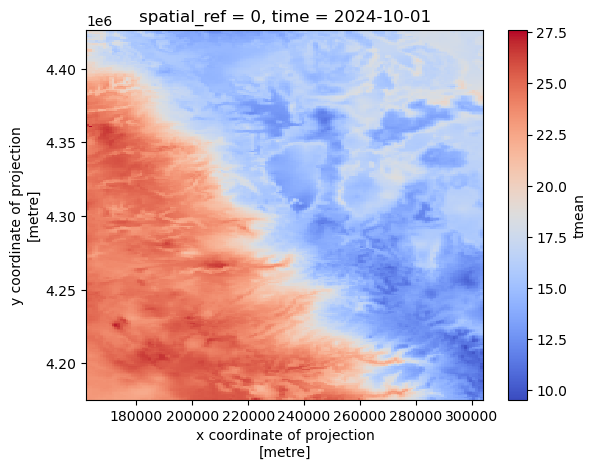

In [21]:
# 2. Build PRISM daily → 1 km grid

# Build source grid (assumes regular lon/lat grid)
lons = np.sort(prism["lon"].unique())
lats = np.sort(prism["lat"].unique())[::-1]  # north → south

nx_src = len(lons)
ny_src = len(lats)

# Map for fast reshaping
def prism_day_to_xarray(df_day, var, lats, lons, ny_src, nx_src):
    df_sorted = df_day.sort_values(["lat", "lon"], ascending=[False, True])
    
    arr = df_sorted[var].to_numpy().reshape(ny_src, nx_src)

    da = xr.DataArray(
        arr,
        dims=("lat", "lon"),
        coords={"lat": lats, "lon": lons},
        name=var,
    )

    # Tell rioxarray which dims are spatial
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    da = da.rio.write_crs("EPSG:4326", inplace=False)

    return da

daily_dates = np.sort(prism["date"].unique())
prism_daily_1km = []

for d in daily_dates:
    df_d = prism[prism["date"] == d]

    day_vars = {}
    for v in ["tmin", "tmax", "tmean", "tdmean", "ppt"]:
        da = prism_day_to_xarray(df_d, v, lats, lons, ny_src, nx_src)
        # print(da.dims, da.shape, da.rio.crs)

        da_1km = da.rio.reproject(
            dst_crs=TEMPLATE_CRS,
            transform=TEMPLATE_TRANSFORM,
            shape=(NY, NX),
            resampling=Resampling.bilinear,
        )

        day_vars[v] = da_1km


    ds_day = xr.Dataset(day_vars).assign_coords(time=d)
    prism_daily_1km.append(ds_day)

prism_daily_1km = xr.concat(prism_daily_1km, dim="time")
print(prism_daily_1km)
prism_daily_1km["tmin"].min().item(), prism_daily_1km["tmax"].max().item()

prism_daily_1km["tmean"].isel(time=0).plot(cmap="coolwarm")


<xarray.Dataset> Size: 7GB
Dimensions:          (time: 5856, y: 251, x: 142)
Coordinates:
  * x                (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * y                (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
    spatial_ref      int64 8B 0
  * time             (time) datetime64[ns] 47kB 2024-10-01 ... 2025-06-01T23:...
Data variables:
    prism_tair       (time, y, x) float64 2GB 18.34 18.15 17.08 ... 14.08 13.39
    prism_tmean      (time, y, x) float64 2GB 18.34 18.15 17.08 ... 12.74 12.2
    prism_tdmean     (time, y, x) float64 2GB 0.09683 -0.016 ... -0.1875 -0.1554
    prism_ppt_daily  (time, y, x) float64 2GB nan nan nan nan ... 0.0 0.0 0.1455


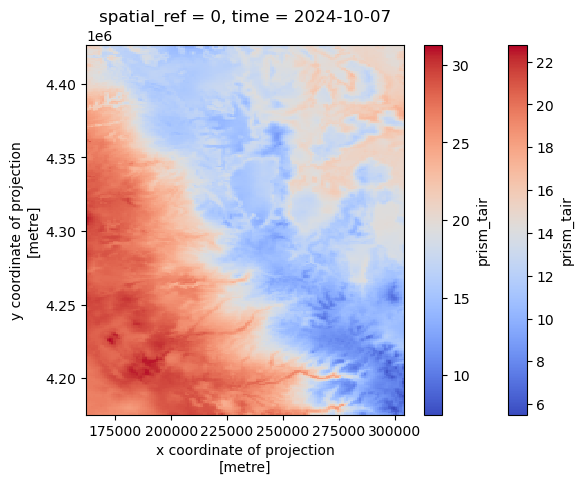

In [22]:
# 3. Expand PRISM daily → hourly via diurnal interpolation
hourly_datasets = []

for h in range(24):
    t_air = diurnal_temperature(
        prism_daily_1km["tmin"],
        prism_daily_1km["tmax"],
        h,
    )

    ds_h = xr.Dataset(
        {
            "prism_tair": t_air,
            "prism_tmean": prism_daily_1km["tmean"],
            "prism_tdmean": prism_daily_1km["tdmean"],
            "prism_ppt_daily": prism_daily_1km["ppt"],
        }
    )

    ds_h = ds_h.assign_coords(
        time=prism_daily_1km["time"] + np.timedelta64(h, "h")
    )

    hourly_datasets.append(ds_h)

prism_hourly_1km = xr.concat(hourly_datasets, dim="time")
print(prism_hourly_1km)
prism_hourly_1km["prism_tair"].min().item(), prism_hourly_1km["prism_tair"].max().item()

prism_hourly_1km["prism_tair"].sel(
    time=prism_hourly_1km.time[15]
).plot(cmap="coolwarm")

prism_hourly_1km["prism_tair"].sel(
    time=prism_hourly_1km.time[6]
).plot(cmap="coolwarm")


<xarray.DataArray 'prism_tair' (time: 5856)> Size: 47kB
array([16.14876598, 18.01017115, 17.9764668 , ..., 16.97376925,
       20.25588679, 20.59364424], shape=(5856,))
Coordinates:
    x            float64 8B 2.336e+05
    y            float64 8B 4.301e+06
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 47kB 2024-10-01 ... 2025-06-01T23:00:00


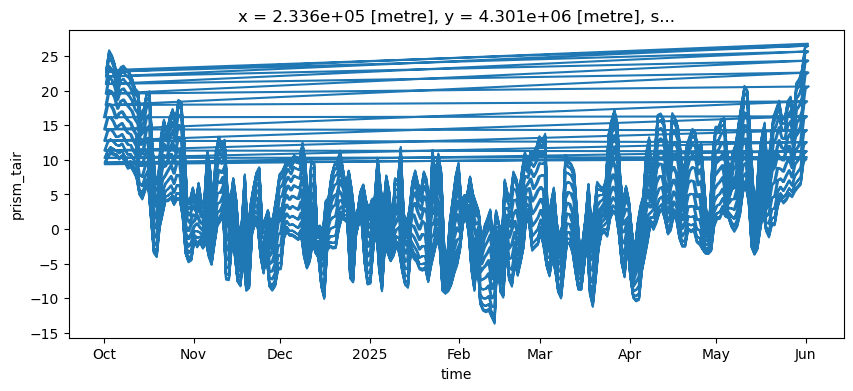

In [26]:
iy = NY // 2
ix = NX // 2

ts = prism_hourly_1km["prism_tair"].isel(y=iy, x=ix)
print(ts)
ts.plot(figsize=(10, 4))


In [ ]:
# 4. Load IMERG hourly parquet (already processed)

imerg = pd.read_parquet(IMERG_PARQUET)
imerg.head()
imerg.info()
imerg.describe()

imerg["hour_utc"] = pd.to_datetime(imerg["hour_utc"]).dt.floor("H")

# Convert IMERG to xarray (assumes lon/lat grid)
imerg_lons = np.sort(imerg["lon"].unique())
imerg_lats = np.sort(imerg["lat"].unique())[::-1]  # north → south

NXI = len(imerg_lons)
NYI = len(imerg_lats)

def imerg_to_xarray(df_hour, lats, lons, nyi, nxi):
    df_sorted = df_hour.sort_values(
        ["lat", "lon"],
        ascending=[False, True]   # north → south
    )

    arr = df_sorted["plp"].to_numpy().reshape(nyi, nxi)

    da = xr.DataArray(
        arr,
        dims=("lat", "lon"),
        coords={"lat": lats, "lon": lons},
        name="imerg_plp",
    )

    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    da = da.rio.write_crs("EPSG:4326", inplace=False)

    return da


imerg_hourly = []
for t in np.sort(imerg["hour_utc"].unique()):
    df_t = imerg[imerg["hour_utc"] == t]
    da = imerg_to_xarray(df_t, imerg_lats, imerg_lons, NYI, NXI)

    da_1km = da.rio.reproject(
        dst_crs=TEMPLATE_CRS,
        transform=TEMPLATE_TRANSFORM,
        shape=(NY, NX),
        resampling=Resampling.bilinear,
    )

    imerg_hourly.append(
        da_1km.to_dataset().assign_coords(time=t)
    )

imerg_hourly_1km = xr.concat(imerg_hourly, dim="time")
print(imerg_hourly_1km)


<class 'pandas.core.frame.DataFrame'>
Index: 6966000 entries, 1 to 7358128
Data columns (total 5 columns):
 #   Column    Dtype              
---  ------    -----              
 0   hour_utc  datetime64[ns, UTC]
 1   lat       float64            
 2   lon       float64            
 3   plp       float64            
 4   elev      float32            
dtypes: datetime64[ns, UTC](1), float32(1), float64(3)
memory usage: 292.3 MB


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_30228\3000803141.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  imerg["hour_utc"] = pd.to_datetime(imerg["hour_utc"]).dt.floor("H")


<xarray.Dataset> Size: 1GB
Dimensions:      (time: 5160, y: 251, x: 142)
Coordinates:
  * x            (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * y            (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
    spatial_ref  int64 8B 0
  * time         (time) object 41kB 2024-10-11 00:00:00+00:00 ... 2025-05-30 ...
Data variables:
    imerg_plp    (time, y, x) float64 1GB 100.0 100.0 100.0 ... 100.0 100.0


KeyError: "No variable named 'plp'. Variables on the dataset include ['imerg_plp', 'x', 'y', 'spatial_ref', 'time']"

In [32]:
imerg_hourly_1km["imerg_plp"].min().item(), imerg_hourly_1km["imerg_plp"].max().item()

(0.0, 100.00000000000003)

In [34]:
# 5. Synchronize time and check

common_times = np.intersect1d(
    prism_hourly_1km["time"].values,
    imerg_hourly_1km["time"].values,
)

# Normalize time coordinates (drop tz)
prism_hourly_1km = prism_hourly_1km.assign_coords(
    time=pd.to_datetime(prism_hourly_1km.time.values).tz_localize(None)
)

imerg_hourly_1km = imerg_hourly_1km.assign_coords(
    time=pd.to_datetime(imerg_hourly_1km.time.values).tz_localize(None)
)

# Align safely
prism_hourly_1km, imerg_hourly_1km = xr.align(
    prism_hourly_1km,
    imerg_hourly_1km,
    join="inner"
)

assert prism_hourly_1km.time.equals(imerg_hourly_1km.time)
assert prism_hourly_1km.dims["time"] > 0



C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_30228\245762261.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert prism_hourly_1km.dims["time"] > 0


In [37]:
# Write to netcdfs


prism_enc = {
    v: {"zlib": True, "complevel": 4}
    for v in prism_hourly_1km.data_vars
}
prism_hourly_1km.to_netcdf(
    PRISM_OUT,
    format="NETCDF4",
    encoding=prism_enc,
)
print(f"Wrote {PRISM_OUT}")


imerg_enc = {
    v: {"zlib": True, "complevel": 4}
    for v in imerg_hourly_1km.data_vars
}
imerg_hourly_1km.to_netcdf(
    IMERG_OUT,
    format="NETCDF4",
    encoding=imerg_enc,
)
print(f"Wrote {IMERG_OUT}")


Wrote C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\prism_hourly_1km.nc
Wrote C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\imerg_hourly_1km.nc


In [38]:
ds = xr.open_dataset(PRISM_OUT)
print(ds)


<xarray.Dataset> Size: 6GB
Dimensions:          (time: 5160, y: 251, x: 142)
Coordinates:
  * x                (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * y                (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * time             (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:...
Data variables:
    prism_tair       (time, y, x) float64 1GB ...
    prism_tmean      (time, y, x) float64 1GB ...
    prism_tdmean     (time, y, x) float64 1GB ...
    prism_ppt_daily  (time, y, x) float64 1GB ...
    spatial_ref      int64 8B ...
